<a href="https://colab.research.google.com/github/jimenami/master_ciencia_datos/blob/main/DATA_MINING/Copia_de_DM2025_Sesgos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción

En esta sesión vamos a comprobar los efectos de los sesgos sobre los algoritmos de machine learning y vamos a realizar un análisis más en profundidad de dichos efectos, así como de las acciones que se deberían de tomar cuando estos aparezcan.

## Ejercicio 1


Para empezar, carga el dataset del titanic del ejercicio 3 que te proporcionamos.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving TitanicEjemploSes3.csv to TitanicEjemploSes3.csv


In [ ]:
import pandas as pd
df_titanic = pd.read_csv("TitanicEjemploSes3.csv", sep =';')
df_titanic.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


El siguiente fragmento de código ya te deja preparado el dataset para el entrenamiento del modelo de ML. Simplemente ejecuta el código.

In [ ]:
# El siguiente paso es separar las etiquetas de predicción de los datos de train
# A continuación, hay que realizar operaciones de one-hot-encoding sobre las variables
# categóricas, ya que SVC trabaja con distancias y necesitamos
# realizar dichas operaciones para poder trabajar con las etiquetas

aux = df_titanic[["Survived","Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]]
aux = aux.dropna()

labels = aux["Survived"]
aux = aux.drop(columns=["Survived"])
df_base= pd.get_dummies(aux, drop_first=True, columns=["Sex","Embarked"])

Entrenamos el modelo basado en DecissionTree. Simplemente ejecuta, y compara los resultados de los distintos KFold para la métrica de Accuracy. Es importante que mantengas la semilla del KFold (random_state=50)

In [ ]:
X = df_base
y = labels
X.head()


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [ ]:
from numpy import random
from sklearn import tree
from sklearn.model_selection import cross_val_score, KFold, cross_validate
from sklearn.metrics import accuracy_score

cv = KFold(n_splits = 5, shuffle = True, random_state= 50)
model = tree.DecisionTreeClassifier()
i = 0
for train_idx, test_idx in cv.split(X):
  X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
  y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
  model.fit(X_train,y_train)
  predicciones = model.predict(X_test)
  accuracy = accuracy_score(y_test, predicciones)
  i +=1
  print(f"Fold: {i}, accuracy: {accuracy:.4f}")
  print("-" * 30)


Fold: 1, accuracy: 0.9551
------------------------------
Fold: 2, accuracy: 0.9663
------------------------------
Fold: 3, accuracy: 0.9438
------------------------------
Fold: 4, accuracy: 0.9318
------------------------------
Fold: 5, accuracy: 0.9432
------------------------------


**1. ¿Qué te parecen los resultados obtenidos?**

En los 5 folds los resultados de accuracy son similares. El único en el que vaja un poco más es en el 4º y en el que es un poco más alto en el segundo que llega a 0.9663.
En general, son accuracies altas, y la variación en los folds se debe a la combinación aleatoria de los datos a la hora de construirlos.

A continuación, obtén los valores de precision, recall y f1_score para cada uno de los folds de los modelos anteriores, y compáralos (para enfoque "micro", y enfoque "macro")

Estos enfoques en el f1-score nos van a servir para ver si el dataset está desbalanceado.

* Enfoque Macro: Calcula la métrica para la Clase 0 y para la Clase 1 por separado, y luego hace la media. Si tu modelo es muy bueno prediciendo la Clase 0 pero muy malo con la Clase 1, el Macro-F1 bajará mucho. Es una métrica "justa" que da el mismo peso a ambas etiquetas.

* Enfoque Micro: En el caso específico de 2 clases, el valor de Micro-Precision, Micro-Recall y Micro-F1 será exactamente el mismo que el Accuracy (Exactitud) del modelo. Esto se debe a que, globalmente, cada error de una clase es un acierto no conseguido de la otra.

Análogo para las métricas de precision y recall.

La recall micro y la precision micro también coincidirán con el accuracy.

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

i = 0
for train_idx, test_idx in cv.split(X):
  X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
  y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
  model.fit(X_train,y_train)
  predicciones = model.predict(X_test)
  precision_macro = precision_score(y_test, predicciones, average= 'macro')
  recall_macro = recall_score(y_test, predicciones, average = 'macro')
  recall_micro = recall_score(y_test, predicciones, average = 'micro')
  f1_macro = f1_score(y_test, predicciones, average = 'macro')
  i +=1
  print(f"Fold: {i}, recall, f1_score y precision micro: {recall_micro:.4f}, recall macro: {recall_macro:.4f}, precision macro: {precision_macro:.4f},  f1 score macro: {f1_macro:.4f}")
  print("-" * 130)

Fold: 1, recall, f1_score y precision micro: 0.9438, recall macro: 0.7380, precision macro: 0.7821,  f1 score macro: 0.7578
----------------------------------------------------------------------------------------------------------------------------------
Fold: 2, recall, f1_score y precision micro: 0.9663, recall macro: 0.6609, precision macro: 0.7385,  f1 score macro: 0.6913
----------------------------------------------------------------------------------------------------------------------------------
Fold: 3, recall, f1_score y precision micro: 0.9438, recall macro: 0.6606, precision macro: 0.8101,  f1 score macro: 0.7074
----------------------------------------------------------------------------------------------------------------------------------
Fold: 4, recall, f1_score y precision micro: 0.9432, recall macro: 0.4882, precision macro: 0.4826,  f1 score macro: 0.4854
---------------------------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**2. ¿Qué tal los resultados ahora? ¿Qué diferencias ves entre el enfoque micro y el macro?**

Como están muy alejados los valores micro de los valores macro, claramente las clases de 'Survived' en el dataset están muy desbalanceadas.
De hecho, en los folds 4 y 5 el f1_score macro está por debajo de 0.5. Al ser esta métrica una media aritmética, eso significa que el modelo ha detectado en torno al 0% de una de las clases. El modelo es peor que el azar clasificando.



Podemos ver cuál es la clase desbalanceada mirando las frecuencias dde la columna 'Survived'

In [ ]:
labels.value_counts()

,count
Survived,
0,425
1,18


Claramente hay muchísimos más datos de pasajeros muertos que supervivientes.


**3. Observa el warning obtenido en la ejecución del programa. ¿Qué crees que significa? ¿Crees que se podría haber evitado de alguna manera modificando el código?**

La fórmula para el Recall es la tasa de verdaderos positivos sobre todos los positivos reales:
$$
Recall = \frac{TP}{TP + FN}
$$  
El warning nos indica que se está dividiendo por 0, es decir, que hay folds en los que hay 0 datos de positivos, de la clase 1, y por defecto el modelo asigna a esos conjuntos recall = 0.

Se podría haber evitado forzando a que en todos los conjuntos haya muestras de clase 1. Esto se puede hacer usando StratifiedKFold en lugar de KFold.

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=50)
i = 0
for train_idx, test_idx in cv.split(X,y):
  X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
  y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
  model.fit(X_train,y_train)
  predicciones = model.predict(X_test)
  precision_macro = precision_score(y_test, predicciones, average= 'macro')
  recall_macro = recall_score(y_test, predicciones, average = 'macro')
  recall_micro = recall_score(y_test, predicciones, average = 'micro')
  f1_macro = f1_score(y_test, predicciones, average = 'macro')
  i +=1
  print(f"Fold: {i}, recall, f1_score y precision micro: {recall_micro:.4f}, recall macro: {recall_macro:.4f}, precision macro: {precision_macro:.4f},  f1 score macro: {f1_macro:.4f}")
  print("-" * 130)

Fold: 1, recall, f1_score y precision micro: 0.9438, recall macro: 0.4941, precision macro: 0.4773,  f1 score macro: 0.4855
----------------------------------------------------------------------------------------------------------------------------------
Fold: 2, recall, f1_score y precision micro: 0.9551, recall macro: 0.8574, precision macro: 0.7440,  f1 score macro: 0.7881
----------------------------------------------------------------------------------------------------------------------------------
Fold: 3, recall, f1_score y precision micro: 0.9326, recall macro: 0.6074, precision macro: 0.6074,  f1 score macro: 0.6074
----------------------------------------------------------------------------------------------------------------------------------
Fold: 4, recall, f1_score y precision micro: 0.9545, recall macro: 0.4941, precision macro: 0.4828,  f1 score macro: 0.4884
---------------------------------------------------------------------------------------------------------------

Ahora son un pelín mejores. Siguen siendo bajos porque las clases siguen estando desbalanceadas, pero ya no sale el warning del recall, luego en todos los folds hay muestras de la clase 1 (aunque haya muy pocas).

## Ejercicio 2

COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) es una herramienta para predecir el riesgo de reincidencia a 2 años que ha sido utilizada en EE.UU. Más en detalle, en función de la puntuación generada por el software, el juez decidia si detener al acusado antes del juicio o en el momento de dictar la sentencia.

En primer lugar, descarga y visualiza el dataset. Para ello, puedes proporcionarle al método de pandas pd.read_csv una url que contenga los datos en raw.

[COMPAS DATASET](https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv)

In [2]:
data_raw = pd.read_csv("https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv", sep=',')
data_raw.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


Imprime por pantalla, el número de acusados por raza.





In [ ]:
data_raw['race'].value_counts()

,count
race,
African-American,3696
Caucasian,2454
Hispanic,637
Other,377
Asian,32
Native American,18


Podemos ver que hay un mayor número de *African-American* y *Caucasian* que de las otras razas. En este caso vamos a centrarnos en las dos razas mencionadas. Por lo que eliminaremos las filas cuya raza no se corresponda con *African-American* o *Caucasian*.


In [3]:
data_new = data_raw[data_raw['race'].isin(['African-American', 'Caucasian'])]
data_new.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0


In [ ]:
data_new['race'].value_counts()

,count
race,
African-American,3696
Caucasian,2454


A partir del dataset, crea dos nuevos dataset.

 Uno con las columnas *age, sex, race, priors_count, score_text*.

1.   Con las columnas columnas *age, sex, race, priors_count, score_text*
2.   Con la columna *two_year_recid*. Esta columna indica si el acusado ha reincidido o no.







In [ ]:
data_new.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='object')

In [4]:
data1 = data_new[['age', 'sex', 'race', 'priors_count','score_text']]
data2 = data_new['two_year_recid']
data1.head()

,age,sex,race,priors_count,score_text
1,34,Male,African-American,0,Low
2,24,Male,African-American,4,Low
3,23,Male,African-American,1,High
6,41,Male,Caucasian,14,Medium
8,39,Female,Caucasian,0,Low


In [ ]:
data2

,two_year_recid
1,1
2,1
3,0
6,1
8,0
...,...
7207,1
7208,0
7209,0
7210,0


Vamos a centrarnos por ahora, en el primer dataset. En primer lugar, vamos a transformarlo en un problema de clasificación binaria. Para ello, en primer lugar, a la columna 'score_text' (puntuación de reincidir) le asignaremos el valor 0 si el riesgo es *Low*, y si el riesgo es Medium o High, le asignaremos el valor 1.



In [ ]:
# Veamos si tiene valores nulos
data1.isnull().sum()

,0
age,0
sex,0
race,0
priors_count,0
score_text,0


In [5]:
data1['score_text'] = data1['score_text'].apply(lambda x: 0 if x == 'Low' else 1)
data1.head()

/tmp/ipykernel_151/2115294374.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['score_text'] = data1['score_text'].apply(lambda x: 0 if x == 'Low' else 1)


,age,sex,race,priors_count,score_text
1,34,Male,African-American,0,0
2,24,Male,African-American,4,0
3,23,Male,African-American,1,1
6,41,Male,Caucasian,14,1
8,39,Female,Caucasian,0,0


Normaliza el resto de variables con el método *get_dummies* de pandas. Recuerda activar drop_first para evitar el problema de la colinearidad.


In [6]:
# Aplicamos get_dummies a las variables categóricas
data1_normalized = pd.get_dummies(data1, drop_first=True, columns=['sex', 'race'])

# Ponemos False = 0 y True = 1
data1_normalized['sex_Male'] = data1_normalized['sex_Male'].apply(lambda x: 0 if x== False else 1)
data1_normalized['race_Caucasian'] = data1_normalized['race_Caucasian'].apply(lambda x: 0 if x== False else 1)


data1_normalized.head()

,age,priors_count,score_text,sex_Male,race_Caucasian
1,34,0,0,1,0
2,24,4,0,1,0
3,23,1,1,1,0
6,41,14,1,1,1
8,39,0,0,0,1



Aplica train_test_split sobre el conjunto de datos, con un tamaño de test de 0.2 y la semilla random_state=42. En este caso, para realizar el train test split, vamos a utilizar el primer dataset como el parámetro X del método, y los valores del segundo dataset como el parámetro Y.

Visualiza x_train, x_test, y_train e y_test. ¿Qué es cada conjunto?

In [7]:
from sklearn.model_selection import train_test_split

X = data1_normalized
y = data2 # ya está en 0 y 1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train)
print(X_test)
print(y_train)
print(y_test)

      age  priors_count  score_text  sex_Male  race_Caucasian
58     53             8           1         1               1
2923   45             7           0         0               1
6253   29             3           0         1               0
530    31             0           0         1               0
4710   25             3           1         1               0
...   ...           ...         ...       ...             ...
4413   20             1           1         1               1
6089   34             4           0         0               1
6132   21             2           1         1               1
6329   31             6           0         1               0
1028   42            13           1         1               0

[4920 rows x 5 columns]
      age  priors_count  score_text  sex_Male  race_Caucasian
3299   21             1           1         1               0
7192   32             0           0         1               1
6147   49            10           0         1

Considerando el conjunto "x_train", cuya variable a predecir es *score_text*, entrena un árbol de decisión.



In [8]:
from sklearn import tree
tree = tree.DecisionTreeClassifier()
tree.fit(X_train[['age', 'priors_count', 'sex_Male','race_Caucasian']], X_train['score_text'] )

DecisionTreeClassifier()

Vamos a simular un funcionamiento real. Por lo que evaluaremos el modelo sobre las prediciones realizadas para el conjunto *x_test* (sin la columna *score_text*), y evaluaremos como ha ido en un hipotético caso real, donde las etiquetas reales (si ha reincidido o no) las tendremos en el conjunto *y_test*. Obten las medidas Accuracy y F1-score.

In [11]:
prediction = tree.predict(X_test[['age', 'priors_count', 'sex_Male','race_Caucasian']])
accuracy = accuracy_score(y_test, prediction)
f1 = f1_score(y_test, prediction)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.6431
F1-score: 0.5901


Obten la importancia de caracteristicas del modelo.

In [12]:
importancias = tree.feature_importances_
df = pd.DataFrame({'feature': ['age', 'priors_count', 'sex_Male','race_Caucasian'], 'importancia': importancias})
print(df)

          feature  importancia
0             age     0.476417
1    priors_count     0.428912
2        sex_Male     0.046348
3  race_Caucasian     0.048322


Calcula además el TPR(sensitivity) y el FPR(precision) en función de la raza.

In [13]:
# El TPR o sensibilidad es el recall

from sklearn.metrics import confusion_matrix

# Creamos una función para no repetir código
def calcular_tasas(y_real, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()
    tpr = tp / (tp + fn) # Sensibilidad
    fpr = fp / (fp + tn) # Falsa alarma. Falsos positivos/ negativos reales
    return tpr, fpr

# 1. Separamos las predicciones y realidades por grupo
# Grupo: Caucasian (race_Caucasian == 1)
mask_caucasian = X_test['race_Caucasian'] == 1
y_test_cau = y_test[mask_caucasian]
pred_cau = prediction[mask_caucasian]

# Grupo: African-American (race_Caucasian == 0)
mask_afro = X_test['race_Caucasian'] == 0
y_test_afro = y_test[mask_afro]
pred_afro = prediction[mask_afro]

# 2. Calculamos las métricas
tpr_cau, fpr_cau = calcular_tasas(y_test_cau, pred_cau)
tpr_afro, fpr_afro = calcular_tasas(y_test_afro, pred_afro)

print(f"--- Caucásicos ---")
print(f"TPR: {tpr_cau:.4f} | FPR: {fpr_cau:.4f}")

print(f"\n--- Afroamericanos ---")
print(f"TPR: {tpr_afro:.4f} | FPR: {fpr_afro:.4f}")

--- Caucásicos ---
TPR: 0.3351 | FPR: 0.1716

--- Afroamericanos ---
TPR: 0.6536 | FPR: 0.3582


Podemos ver que ambas tasas son mejores para los Afroamericanos, es decir, el modelo es mejor prediciendo si un Afroamericano va a reincidir o no, pero también hay más falsos positivos.
Esto es porque las clases están ligeramente desbalanceadas. Tenemos más datos de afroamericanos que de caucásicos.

Entrenamos con XGBoostClassifier con los parámetros *use_label_encoder=False, eval_metric='logloss'*, y obtenemos accuracy, f1-score y feature importance. Calcula además el TPR y el FPR en función de la raza.

Analiza y compara los resultados obtenidos de ambos algoritmos.

In [14]:
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train[['age','race_Caucasian','priors_count','sex_Male']], X_train['score_text'])


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:58:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [15]:
prediction = xgb.predict(X_test[['age','race_Caucasian','priors_count','sex_Male']])
accuracy = accuracy_score(y_test, prediction)
f1_score = f1_score(y_test, prediction)

importancias = xgb.feature_importances_
df = pd.DataFrame({'feature': ['age','race_Caucasian','priors_count','sex_Male'], 'importancia': importancias})

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1_score:.4f}")
print(df)

Accuracy: 0.6561
F1-score: 0.6227
          feature  importancia
0             age     0.289530
1  race_Caucasian     0.158709
2    priors_count     0.395717
3        sex_Male     0.156043


Tanto la accuracy como el f1_score son mejores para el XGboost que para el árbol de clasificación.
En cuanto a las importancias, este mmodelo da más importancia a la edad y a la raza, a diferencia del árbol que daba más a la edad y al priors_count.

Obten la matriz de confusión sobre el hipotético caso real. Donde las predicciones serán las realizadas por el modelo sobre el conjunto x_test(sin la columna score_text), y los valores reales del conjunto y_test. Para hacer más sencillo la interpretación de los resultados, vamos a normalizar los resultados mostrados en la matriz de resultados.

In [16]:
# Obtenemos las tasas en función de la raza
# Grupo: Caucasian (race_Caucasian == 1)
mask_caucasian = X_test['race_Caucasian'] == 1
y_test_cau = y_test[mask_caucasian]
pred_cau = prediction[mask_caucasian]

# Grupo: African-American (race_Caucasian == 0)
mask_afro = X_test['race_Caucasian'] == 0
y_test_afro = y_test[mask_afro]
pred_afro = prediction[mask_afro]

# 2. Calculamos las métricas
tpr_cau, fpr_cau = calcular_tasas(y_test_cau, pred_cau)
tpr_afro, fpr_afro = calcular_tasas(y_test_afro, pred_afro)

print(f"--- Caucásicos ---")
print(f"TPR: {tpr_cau:.4f} | FPR: {fpr_cau:.4f}")

print(f"\n--- Afroamericanos ---")
print(f"TPR: {tpr_afro:.4f} | FPR: {fpr_afro:.4f}")

--- Caucásicos ---
TPR: 0.3814 | FPR: 0.1683

--- Afroamericanos ---
TPR: 0.7161 | FPR: 0.4097


Ahora la diferencia en las tasas en función de la raza es mucho más pronunciada.

In [17]:
# Vamos a devolver las matricces de confusión
from sklearn.metrics import confusion_matrix
matriz_caucasian = confusion_matrix(y_test_cau, pred_cau)
matriz_afro = confusion_matrix(y_test_afro, pred_afro)

# Normalizamos las matrices
matriz_caucasian = matriz_caucasian / matriz_caucasian.sum(axis=1, keepdims=True)
matriz_afro = matriz_afro/ matriz_afro.sum(axis=1, keepdims=True)

# Las printeamos
print(f"--- Caucásicos ---")
print(matriz_caucasian)

print(f"\n--- Afroamericanos ---")
print(matriz_afro)

--- Caucásicos ---
[[0.83168317 0.16831683]
 [0.6185567  0.3814433 ]]

--- Afroamericanos ---
[[0.59025788 0.40974212]
 [0.28385417 0.71614583]]


Tanto los falsos negativos como los falsos positivos son mucho mayores en los Afroamericanos.
El modelo tiene casi el doble de probabilidad de clasificar a una persona afroamericana como reincidente sin serlo (0.3639) que a una persona caucásica (0.1716). Claramente el modelo está sesgado.

Además el modelo es más probable qeu diga que un blanco no va a reincidir (falsos negativos = 0.6649) que un negro (0.34375). Es mcuho más indulgente con los caucásicos.

¿Qué observas en los resultados?

Considerando que la parte inferior izquierda de la matriz de confusión, son los falsos negativos y la parte superior derecha de la matriz son los falsos positivos. Añade al dataset una columna que te indique si se ha producido un falso positivo, un falso negativo o la predicción fue correcta.

In [18]:
import numpy as np

# Inicializamos la columna
X_test['resultado_prediccion'] = 'Correcto'

# Asignamos los errores
X_test.loc[(y_test == 0) & (prediction == 1), 'resultado_prediccion'] = 'Falso Positivo'
X_test.loc[(y_test == 1) & (prediction == 0), 'resultado_prediccion'] = 'Falso Negativo'
# Verificamos los primeros resultados
print(X_test[['race_Caucasian', 'resultado_prediccion']].head())

      race_Caucasian resultado_prediccion
3299               0             Correcto
7192               1             Correcto
6147               0       Falso Negativo
5591               0             Correcto
5846               0       Falso Negativo


Una vez que hemos añadido la nueva columna, vamos a centrarnos en los falsos negativos.

In [19]:
falsos_negativos = X_test[X_test['resultado_prediccion'] == 'Falso Negativo']
print(falsos_negativos)

      age  priors_count  score_text  sex_Male  race_Caucasian  \
6147   49            10           0         1               0   
5846   27             0           0         1               0   
6725   54             3           0         1               1   
2230   46             3           0         1               0   
4074   38             0           1         1               0   
...   ...           ...         ...       ...             ...   
4555   33             0           1         1               0   
1215   34             3           1         1               0   
7168   28             0           0         1               1   
6977   28             0           0         1               0   
4800   30             2           0         1               1   

     resultado_prediccion  
6147       Falso Negativo  
5846       Falso Negativo  
6725       Falso Negativo  
2230       Falso Negativo  
4074       Falso Negativo  
...                   ...  
4555       Falso Negati

De esos falsos negativos, obten el número de falsos negativos por raza, y analiza los resultados.


In [20]:
falsos_negativos['race_Caucasian'].value_counts()

,count
race_Caucasian,
1,120
0,109


Ahora vamos a fijarnos en los falsos positivos, obten el número de falsos positivos por raza y analiza los resultados.

In [21]:
falsos_positivos = X_test[X_test['resultado_prediccion'] == 'Falso Positivo']
falsos_positivos['race_Caucasian'].value_counts()

,count
race_Caucasian,
0,143
1,51


Los falsos negativos sí que están más igualados para amvas razas, aunque hay más falsos negarivos en el caso de los afroamericanos. Pero los falsos positivos sí que están muy desequilibrados. Hay muchos más falsos positivos para los afroamericanos que para los caucásicos. El modelo predice que van a reincidir cuando realmente no lo van a hacer.

¿Por qué crees que se produce esto? Haz una gráfica que muestre la puntuación asignada en función de la raza sobre el mismo conjunto sobre el que entrenastes el árbol. Ten en cuenta, que dado que lo habiamos transformado en la variable categórica low y high como la probabilidad de reincidir.

¿Qué observas en los resultados? ¿Donde crees que se produce el sesgo que afecta al modelo?



Total Afroamericanos: 2963
Total Caucásicos: 1957


/tmp/ipykernel_393/3895494340.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Riesgo Asignado')


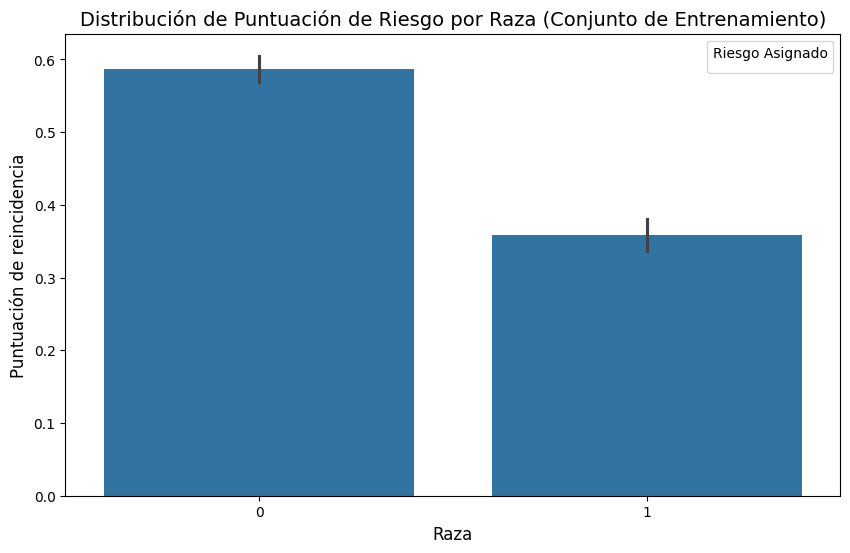

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='race_Caucasian', y='score_text', data=X_train)
plt.title('Distribución de Puntuación de Riesgo por Raza (Conjunto de Entrenamiento)', fontsize=14)
plt.xlabel('Raza', fontsize=12)
plt.ylabel('Puntuación de reincidencia', fontsize=12)
plt.legend(title='Riesgo Asignado')

# Añadimos etiquetas de porcentaje sobre las barras para mejor interpretación
total_afro = len(X_train[X_train['race_Caucasian'] == 0])
total_cau = len(X_train[X_train['race_Caucasian'] == 1])

print(f"Total Afroamericanos: {total_afro}")
print(f"Total Caucásicos: {total_cau}")

plt.show()


Sabemos que score_text = 1 es riesgo medio-alto mientras que score_text = 0 es probabilidad baja de reincidir.
La media de score para afroamericanos está en torno a 0.6, muy cercano a 1, por lo que la mayoría de afroamericanos se clasifican com ocon alto/medio riesgo de reincidir. Mientras que la media de score para los caucásicos es de menos de 0.4, que está pro debajo de 0.5, luego la mayoría queda clasificada como de riesgo bajo.

Ahí está el problema y ahí es donde se porduce el sesgo. En haber agrupado en el mismo grupo a los de probabilidad media y alta. Pues seguramente la mayoría de afroamericanos antes tenían una probabilidad media de reincidir que ahora pagan el mismo "castigo" que los que sí son reincidentes.

In [ ]:
# Podemos hacer un conteo de los caucásicos con probabilidad media de reincidir vs los afroamericanos, en el dataset original.
data1 = data_new[['age', 'sex', 'race', 'priors_count','score_text']]

data_cau = data1[data1['race'] == 'Caucasian']
data_afro = data1[data1['race'] == 'African-American']

print("score_text para los caucásicos:")
data_cau['score_text'].value_counts()


score_text para los caucásicos:


,count
score_text,
Low,1600
Medium,578
High,276


In [ ]:
print("score_text para los afroamericanos:")
data_afro['score_text'].value_counts()

score_text para los afroamericanos:


,count
score_text,
Low,1522
Medium,1149
High,1025


Además de que, de primeras ya habíua disparidad en el grupo high en función de la raza, a pesar de que la clase low para ambos grupos es muy similar, el agrupamiento de las clases Medium y High genera un sesgo por diseño, ya que asigna una etiqueta de riesgo al 58.8% de la población afroamericana frente al 34.8% de la caucásica, facilitando que el algoritmo utilice la raza como un predictor de alta importancia estadística.

Repite el mismo ejercicio, pero esta vez, elimina la variable raza del conjunto de entrenamiento.

In [ ]:
from sklearn import tree

tree = tree.DecisionTreeClassifier()
tree.fit(X_train[['age', 'priors_count', 'sex_Male']], X_train['score_text'])

DecisionTreeClassifier()

Obten las medidas de Accuracy y F1-Score sobre el nuevo modelo. Obten además el TPR y el FPR en función de la raza. Compara y analiza los resultados con el anterior modelo.

In [ ]:
prediction = tree.predict(X_test[['age', 'priors_count', 'sex_Male']])
accuracy = accuracy_score(y_test, prediction)
f1_score = f1_score(y_test, prediction)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1_score:.4F}")

Accuracy: 0.6593
F1-score: 0.6124


In [ ]:
# Obtenemos las tasas TPR y FPR en función de la raza

mask_caucasian = X_test['race_Caucasian'] == 1
mask_afro = X_test['race_Caucasian'] == 0

y_test_cau = y_test[mask_caucasian]
y_test_afro = y_test[mask_afro]

pred_cau = prediction[mask_caucasian]
pred_afro = prediction[mask_afro]

tpr_cau, fpr_cau = calcular_tasas(y_test_cau, pred_cau)
tpr_afro, fpr_afro = calcular_tasas(y_test_afro, pred_afro)

print(f"--- Caucásicos ---")
print(f"TPR: {tpr_cau:.4f} | FPR: {fpr_cau:.4f}")

print(f"\n--- Afroamericanos ---")
print(f"TPR: {tpr_afro:.4f} | FPR: {fpr_afro:.4f}")

--- Caucásicos ---
TPR: 0.4175 | FPR: 0.1815

--- Afroamericanos ---
TPR: 0.6510 | FPR: 0.3352


Antes el resultado de estas tasas era:

--- Caucásicos ---
TPR: 0.3814 | FPR: 0.1683

--- Afroamericanos ---
TPR: 0.7161 | FPR: 0.4097

Pro lo que podemos ver que ahora mismo la diferencia se ha reducido.

Obten los coeficientes

In [ ]:
importances = tree.feature_importances_
df = pd.DataFrame({'feature': ['age', 'priors_count', 'sex_Male'], 'importancia': importances})
print(df)

        feature  importancia
0           age     0.498959
1  priors_count     0.460827
2      sex_Male     0.040214


El modelo da casi toda la importancia a la edad y a si tiene delitos anteriores.

Entrenamos XGBoost para el mismo conjunto de datos sin la variable raza y con los parámetros  *use_label_encoder=False, eval_metric='logloss'*, obtenemos accuracy, f1-score y feature importance. Obten además el TPR y el FPR en función de la raza.  Analiza el feature Importance de XGBoost antes y despues de eliminar la variable raza.

In [31]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train[['age','priors_count','sex_Male']], X_train['score_text'])
prediction = xgb.predict(X_test[['age','priors_count','sex_Male']])
accuracy = accuracy_score(prediction, y_test)
F1_score = f1_score(prediction, y_test, average = 'macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"f1_score: {F1_score:.4f}")


Accuracy: 0.6593
f1_score: 0.6552


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:32:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Teníamos que antes las métricas considerando la raza como variable para el XGBoost eran:
Accuracy: 0.6561
F1-score: 0.6227

El accuracy ha mejorado ligeramente pero el F1_Score ha empeorado.

In [37]:
#  Calculamos las importancias de las variables

importances = xgb.feature_importances_
df = pd.DataFrame({'feature':['age', 'sex_Male', 'priors_count'],'importance': importances})
print(df)

        feature  importance
0           age    0.364470
1      sex_Male    0.472286
2  priors_count    0.163244


Si recordamos, el fearture_importance antes de eliminar la raza era:
$$
\begin{matrix}
  &        feature  & importancia\\
0 &            age   &  0.289530\\
1  & race\_Caucasian &    0.158709\\
2  &  priors\_count   &  0.395717\\
3     &   sex\_Male &    0.156043\\
\end{matrix}
$$



In [38]:
#  Calculamos los ratios TPR, FPR en función de la raza para este modelo
mask_caucasian = X_test['race_Caucasian'] == 1
mask_afro = X_test['race_Caucasian'] == 0

y_test_cau = y_test[mask_caucasian]
y_test_afro = y_test[mask_afro]

pred_cau = prediction[mask_caucasian]
pred_afro = prediction[mask_afro]

tpr_cau, fpr_cau = calcular_tasas(y_test_cau, pred_cau)
tpr_afro, fpr_afro = calcular_tasas(y_test_afro, pred_afro)

print(f"--- Caucásicos ---")
print(f"TPR: {tpr_cau:.4f} | FPR: {fpr_cau:.4f}")

print(f"\n--- Afroamericanos ---")
print(f"TPR: {tpr_afro:.4f} | FPR: {fpr_afro:.4f}")


--- Caucásicos ---
TPR: 0.4072 | FPR: 0.1815

--- Afroamericanos ---
TPR: 0.6745 | FPR: 0.3553


Si recordamos estas tasas para el modelo con la variable raza antes eran:

--- Caucásicos ---
TPR: 0.3814 | FPR: 0.1683

--- Afroamericanos ---
TPR: 0.7161 | FPR: 0.4097

por lo qe podemos ver que la diferencia se ha reducido bastante, más que para el árbol de clasificación de hecho.

Dibuja la matriz de confusión

In [43]:
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_test, prediction)
#convertimos a dataframe
matrix = pd.DataFrame(matrix)
# renombramos las columnas
matrix.columns = ['Predicted 0', 'Predicted 1']
matrix.index = ['Actual 0', 'Actual 1']

print(matrix)

          Predicted 0  Predicted 1
Actual 0          473          179
Actual 1          240          338


Selecciona los falsos negativos y los falsos positivos.

In [50]:
FN = matrix.iloc[1,0]
FP = matrix.iloc[0,1]
print("Falsos negativos:", FN)
print("Falsos positivos:", FP)

Falsos negativos: 240
Falsos positivos: 179


Aunque no hemos utilizado en este caso la variable raza, añade la columna raza sobre el nuevo conjunto con falsos positivos y negativos y analiza de nuevos los resultados.

In [58]:
# Añadimos la variable raza
# 1. Creamos el DataFrame de análisis usando el índice de X_test
df_resultados = pd.DataFrame({
    'real': y_test,
    'prediccion': prediction,
    'race_Caucasian': X_test['race_Caucasian']
})
# Definimos los tipos de error
def categorizar(row):
    if row['real'] == row['prediccion']:
        return 'Acierto'
    elif row['real'] == 0 and row['prediccion'] == 1:
        return 'Falso Positivo'
    else:
        return 'Falso Negativo'

df_resultados['resultado'] = df_resultados.apply(categorizar, axis=1)

# Contamos los FN y los FP
falsos_negativos = df_resultados[df_resultados['resultado']== 'Falso Negativo']
falsos_positivos = df_resultados[df_resultados['resultado'] == 'Falso Positivo']

falsos_negativos['race_Caucasian'].value_counts()


,count
race_Caucasian,
0,125
1,115


Mira ahora los falsos positivos

In [59]:
falsos_positivos['race_Caucasian'].value_counts()

,count
race_Caucasian,
0,124
1,55


Analiza y compara los resultados de los modelos. ¿Qué observas?



Ahora están mucho más igualados que antes. Aunque el ratio de falsos positivos entre las razas sigue siendo más pronunciado que el de los falsos negativos, ahora la diferencia es un poco más pequeña.

No obstante, el modelo sigue clasificando a muchos más afroamericanos como reincidentes cuando realmente no lo son que a caucásicos.

¿A qué crees que se debe este sesgo? El algoritmo, no es racista, es una función optimizadora que ha aprendido eso. Explora el resto de variables a ver si identificas algun tipo de sesgo que puede estar influyendo en este caso. Por ejemplo, visualiza score_text en función de la raza para el primer caso. ten en cuenta que los datos a utilizar para la visualización, son los de x_test.

¿Qué observas en la visualización?

/tmp/ipykernel_151/4151000682.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Riesgo Asignado')


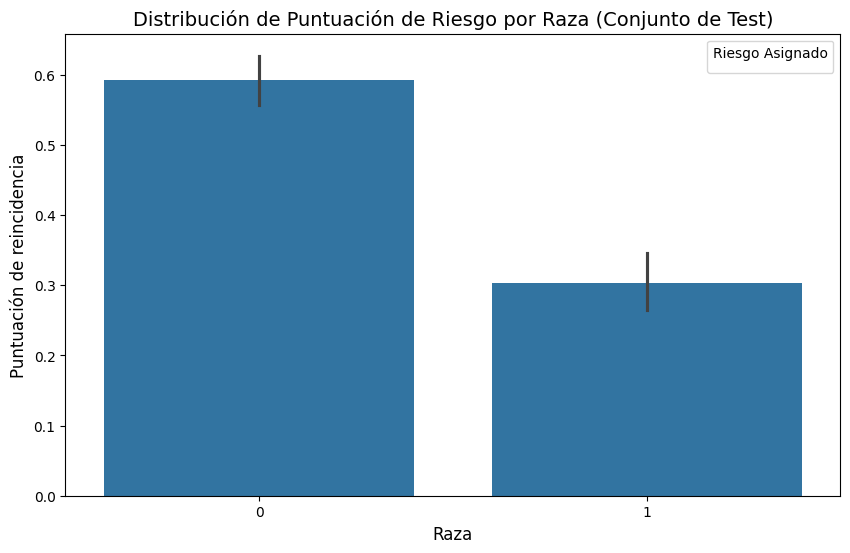

In [61]:
# Vamos a visualizar score_text en función de la raza
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10,6))
sns.barplot(x='race_Caucasian', y='score_text', data=X_test)
plt.title('Distribución de Puntuación de Riesgo por Raza (Conjunto de Test)', fontsize=14)
plt.xlabel('Raza', fontsize=12)
plt.ylabel('Puntuación de reincidencia', fontsize=12)


La forma en la que se ha creado el dataset ya está sesgada de por sí, porque ya se ha asignado de media una mayor puntuación de reincidencia a las personas afroamericanas que a las personas caucásicas.

Una manera de identificar sesgos en los datos, es realizar un EDA, exploratory data analysis. Un primer paso es plotear unas variables contra otras para ver tendencias o identificar a priori posibles variables que puedan producir sesgos.

En la vida real, es casi imposible balancear perfectamente todas las clases, ya que generalmente nos nutrimos de la mayor cantidad de datos posibles, por eso es importante este tipo de analisis.

Para el caso del dataset COMPAS, donde tenemos un gran conjunto de variables categoricas binarias (a excepción de edad) lo que
hace que la visualización entre variables sea tambien muy binaria (más que una distribución), tambien ver la distribución de
una única variable nos puede dar pistas.

Para ello, vamos a utilizar el conjunto de datos completo, con las columnas *age, sex, race, priors_count, score_text y recid*.

Haz diferentes visualizaciones utilizando la función de seaborn sns.pairplot utilizando la columna *race* para el parámetro *hue*.

Analiza los resultados

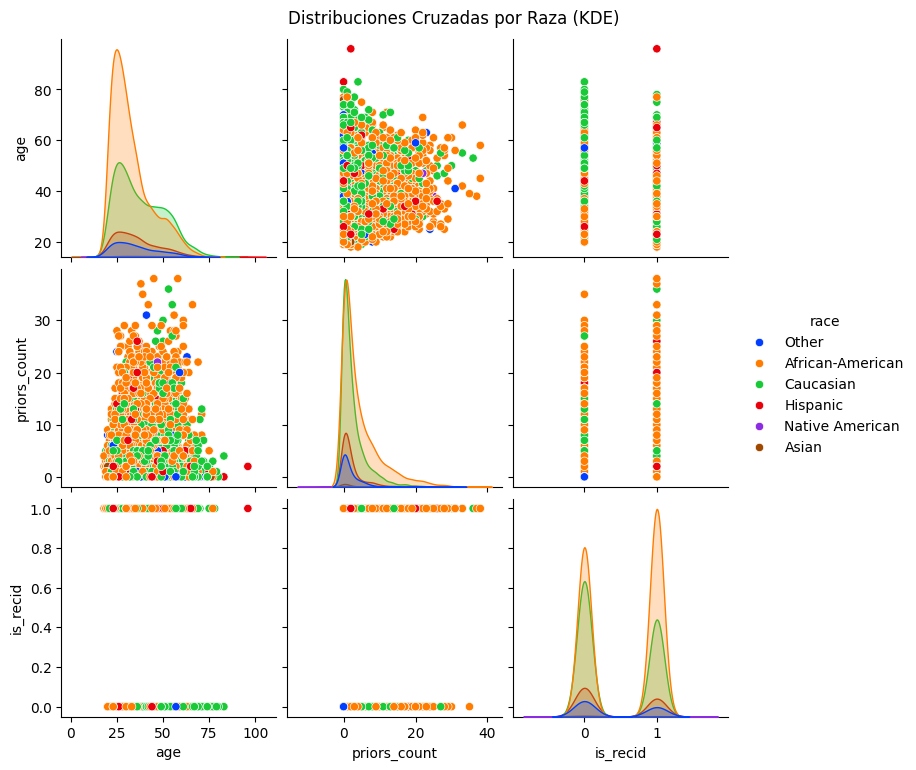

In [63]:
data = data_raw[['age', 'sex', 'race', 'priors_count','score_text','is_recid']]
# Visualización 1: El pairplot clásico con distribuciones de densidad
sns.pairplot(data, hue='race', palette='bright', diag_kind='kde')
plt.suptitle('Distribuciones Cruzadas por Raza (KDE)', y=1.02)
plt.show()



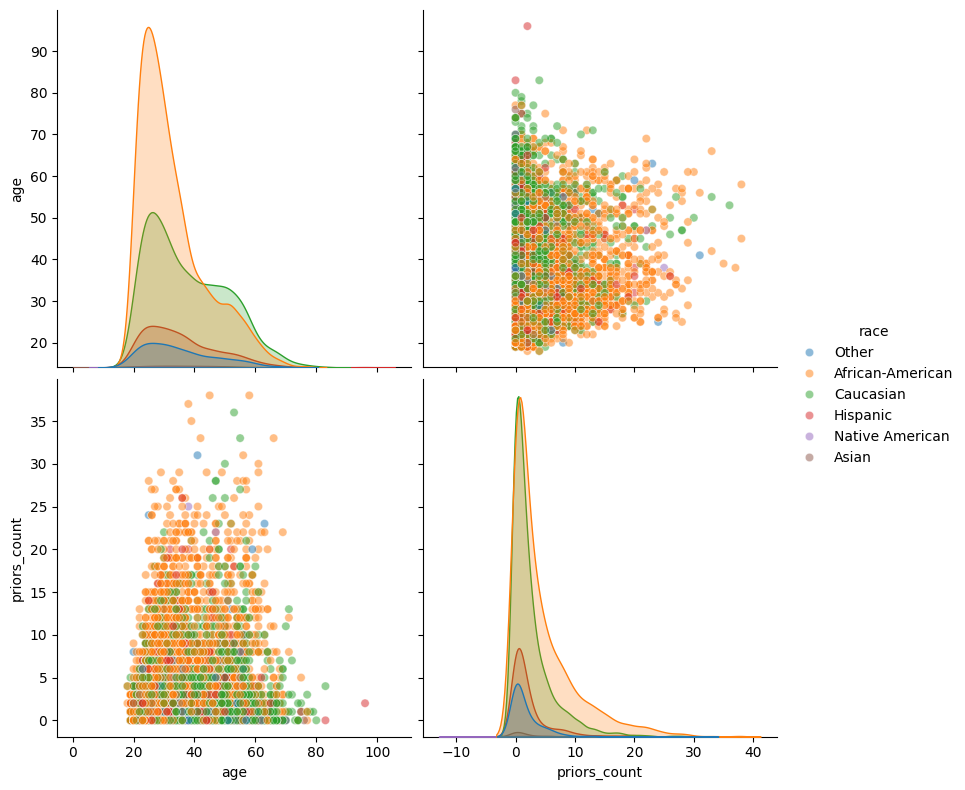

In [64]:
# Visualización 2: Centrado en variables clave para ver el solapamiento de priors_count y age
sns.pairplot(data, vars=['age', 'priors_count'], hue='race',
             plot_kws={'alpha': 0.5}, height=4)
plt.show()

Si nos fijamos en la edad, la mayoría de la población afroamericana de la muestra es mucho más joven que en las otras razas puesto que el pico de la distribución está a mucha diferencia de altura con respecto a las demás.
Y, si recordamos, la edad era una de las variables (si no la más) a la que los modelos daban importancia a la hora de predecir si el sujeto iba a reincidir o no.
Por lo que parte del sesgo existente tamibién recae en este hecho.

Y como vemos en el gráfico de correlación entre priors_count y age, estas variables están muy correlacionadas para todas las razas, no solo para la afroamericana.